In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ot

In [8]:
# Problem size
n1 = 25
n2 = 50

# Generate random data
np.random.seed(0)
a = ot.utils.unif(n1)  # Weights of points in the source domain
b = ot.utils.unif(n2)  # Weights of points in the target domain

x1 = np.random.randn(n1, 2)  # Source points
x1 /= np.sqrt(np.sum(x1 ** 2, axis=1, keepdims=True)) / 2       # Normalize to lie on the unit circle

x2 = np.random.randn(n2, 2)  # Target points
x2 /= np.sqrt(np.sum(x2 ** 2, axis=1, keepdims=True)) / 4       # Normalize to lie on the unit circle

# Compute the cost matrix
C = ot.dist(x1, x2)  # Squared Euclidean cost matrix by default

### Unbalanced Optimal Transport

Unbalanced OT relaxes the marginal constraints and allows for the source and target total weights to be different. The `ot.solve_sample()` function can be used to solve the unbalanced OT problem by setting the marginal penalization `unbalanced` parameter to a positive value.

In [9]:
# Solve the unbalanced OT problem with KL penalization
P_unb_kl = ot.solve_sample(x1, x2, a, b, unbalanced=5e-2).plan

# Unbalanced with KL penalization ad KL regularization
P_unb_kl_reg = ot.solve_sample(x1, x2, a, b, unbalanced=5e-2, reg=1e-1).plan    # Also regularized

# Unbalanced with L2 penalization
P_unb_l2 = ot.solve_sample(x1, x2, a, b, unbalanced=7e-1, reg_type="L2").plan

print(P_unb_kl)
print(P_unb_kl_reg)
print(P_unb_l2)

[[2.60690304e-275 4.01506558e-245 2.60772583e-141 ... 9.13645699e-026
  4.80058543e-225 3.71026013e-301]
 [1.22460798e-163 4.60701018e-302 1.16640612e-039 ... 1.86780969e-064
  1.13469646e-099 9.83186420e-258]
 [1.11086507e-301 7.58311142e-153 1.80595716e-235 ... 2.33585584e-072
  6.69916626e-291 5.91353058e-258]
 ...
 [2.84011475e-102 4.24221444e-038 1.45164957e-246 ... 1.91812475e-294
  1.51371959e-166 1.18188639e-033]
 [1.25942369e-025 1.85282747e-183 3.26459914e-082 ... 7.26114293e-246
  1.26532689e-031 6.40722412e-076]
 [8.21226514e-044 1.03916282e-091 3.62865087e-172 ... 7.16949475e-298
  5.74567900e-090 4.61494191e-027]]
[[2.42838626e-137 3.44613457e-122 4.86236475e-070 ... 2.62943919e-012
  3.98652260e-112 9.31094326e-150]
 [1.37365042e-081 9.63424340e-151 2.68387632e-019 ... 9.81209036e-032
  1.59959114e-049 3.95576067e-128]
 [1.99020299e-150 5.94595161e-076 5.08023050e-117 ... 1.66920782e-035
  5.91247556e-145 4.66690193e-128]
 ...
 [1.05696471e-050 1.47713378e-018 1.51281803

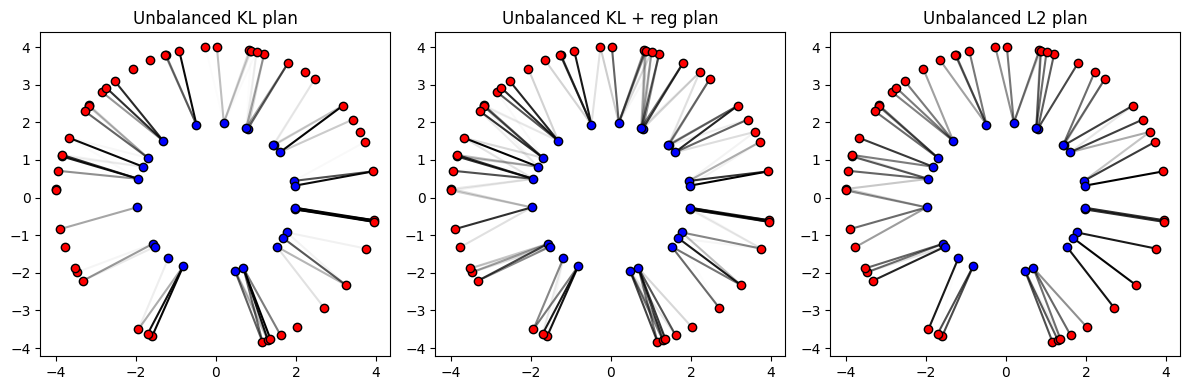

In [10]:
plt.figure(figsize=(12, 4))

# Left plot: Unbalanced KL plan
plt.subplot(1, 3, 1)
thresh_kl = np.max(P_unb_kl) * 1e-2
for i in range(n1):
    for j in range(n2):
        if P_unb_kl[i, j] > thresh_kl:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_unb_kl[i, j] / np.max(P_unb_kl)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('Unbalanced KL plan')

# Middle plot: Unbalanced KL + reg plan
plt.subplot(1, 3, 2)
thresh_kl_reg = np.max(P_unb_kl_reg) * 1e-2
for i in range(n1):
    for j in range(n2):
        if P_unb_kl_reg[i, j] > thresh_kl_reg:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_unb_kl_reg[i, j] / np.max(P_unb_kl_reg)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('Unbalanced KL + reg plan')

# Right plot: Unbalanced L2 plan
plt.subplot(1, 3, 3)
thresh_l2 = np.max(P_unb_l2) * 1e-2
for i in range(n1):
    for j in range(n2):
        if P_unb_l2[i, j] > thresh_l2:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_unb_l2[i, j] / np.max(P_unb_l2)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('Unbalanced L2 plan')

plt.tight_layout()
plt.show()

### Partial Optimal Transport

In [11]:
# Solve the Unbalanced OT problem with TV penalization (equivalent)
P_part_pen = ot.solve_sample(x1, x2, a, b, unbalanced=3, unbalanced_type="TV").plan

# Solve the Partial OT problem with mass constraints
P_part_const = ot.partial.partial_wasserstein(a, b, C, m=0.5)  # 50% mass transported

print(P_part_pen)
print(P_part_const)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 9.39631345e-03
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.49844098e-08 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 2.29617287e-07 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 7.04763287e-03]
 [5.92201892e-03 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 3.20054836e-03]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


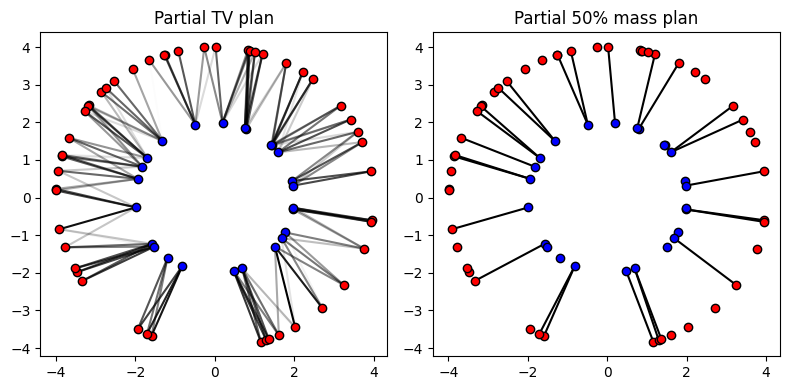

In [12]:
plt.figure(figsize=(8, 4))

# Left plot: Partial TV plan
plt.subplot(1, 2, 1)
thresh_tv = np.max(P_part_pen) * 1e-2
for i in range(n1):
    for j in range(n2):
        if P_part_pen[i, j] > thresh_tv:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_part_pen[i, j] / np.max(P_part_pen)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('Partial TV plan')

# Right plot: Partial 50% mass plan
plt.subplot(1, 2, 2)
thresh_const = np.max(P_part_const) * 1e-2 if np.max(P_part_const) > 0 else 1e-10
for i in range(n1):
    for j in range(n2):
        if P_part_const[i, j] > thresh_const:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_part_const[i, j] / np.max(P_part_const)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('Partial 50% mass plan')

plt.tight_layout()
plt.show()